In [1]:
# | echo: false
# | warning: false
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Dark theme for figures (site handles light mode via CSS filter)
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.labelcolor': '#e0e0e0', 'xtick.color': '#e0e0e0',
    'ytick.color': '#e0e0e0', 'text.color': '#e0e0e0', 'axes.edgecolor': '#444466',
    'axes.grid': True, 'grid.color': '#333355', 'grid.alpha': 0.3,
    'figure.dpi': 150,
})

# Data
cpi = {
    1999: 71.5, 2000: 72.6, 2001: 74.0, 2002: 75.2, 2003: 76.2,
    2004: 77.3, 2005: 78.5, 2006: 80.1, 2007: 82.1, 2008: 84.6,
    2009: 86.6, 2010: 89.0, 2011: 92.8, 2012: 95.7, 2013: 98.5,
    2014: 99.8, 2015: 100.0, 2016: 100.7, 2017: 103.3, 2018: 105.4,
    2019: 107.5, 2020: 108.8, 2021: 111.0, 2022: 120.5, 2023: 130.4,
    2024: 134.0, 2025: 137.5,
}

min_wage_hourly = {
    1999: 3.60, 2000: 3.60, 2001: 4.10, 2002: 4.10, 2003: 4.50,
    2004: 4.85, 2005: 5.05, 2006: 5.35, 2007: 5.52, 2008: 5.73,
    2009: 5.80, 2010: 5.93, 2011: 6.08, 2012: 6.19, 2013: 6.31,
    2014: 6.50, 2015: 6.70, 2016: 7.20, 2017: 7.50, 2018: 7.83,
    2019: 8.21, 2020: 8.72, 2021: 8.91, 2022: 9.50, 2023: 10.42,
    2024: 11.44, 2025: 12.21,
}

pc_start = {
    1999: 16800, 2000: 17133, 2001: 17500, 2002: 18000, 2003: 18500,
    2004: 19200, 2005: 19803, 2006: 20500, 2007: 21100, 2008: 21800,
    2009: 22300, 2010: 22800, 2011: 23000, 2012: 23000, 2013: 19000,
    2014: 19000, 2015: 19000, 2016: 19500, 2017: 19800, 2018: 19971,
    2019: 20880, 2020: 21402, 2021: 21402, 2022: 23556, 2023: 28551,
    2024: 29907, 2025: 31164,
}

pc_pre13_start = {
    1999: 16800, 2000: 17133, 2001: 17500, 2002: 18000, 2003: 18500,
    2004: 19200, 2005: 19803, 2006: 20500, 2007: 21100, 2008: 21800,
    2009: 22300, 2010: 22800, 2011: 23500, 2012: 24000, 2013: 24500,
    2014: 24500, 2015: 24500, 2016: 25000, 2017: 25250, 2018: 25400,
    2019: 25560, 2020: 26199, 2021: 26199, 2022: 28551, 2023: 30549,
    2024: 31497, 2025: 32820,
}

met_start = {
    1999: 21500, 2000: 22000, 2001: 22500, 2002: 23000, 2003: 23500,
    2004: 24000, 2005: 28383, 2006: 29000, 2007: 29500, 2008: 30500,
    2009: 31000, 2010: 31500, 2011: 32000, 2012: 32500, 2013: 30000,
    2014: 30500, 2015: 31000, 2016: 31500, 2017: 32000, 2018: 32500,
    2019: 33500, 2020: 34500, 2021: 34500, 2022: 36500, 2023: 39500,
    2024: 42210, 2025: 44000,
}

years = sorted(pc_start.keys())

def min_wage_annual(h):
    return round(h * 37.5 * 52, 2)

def real_terms(amount, year, base=2025):
    return round(amount * (cpi[base] / cpi[year]), 2)

df = pd.DataFrame({
    'Year': years,
    'PC_Nominal': [pc_start[y] for y in years],
    'PC_Pre13_Nominal': [pc_pre13_start[y] for y in years],
    'Met_Nominal': [met_start[y] for y in years],
    'MinWage_Hourly': [min_wage_hourly[y] for y in years],
})
df['MinWage_Annual'] = df['MinWage_Hourly'].apply(min_wage_annual)
df['PC_Real'] = df.apply(lambda r: real_terms(r['PC_Nominal'], r['Year']), axis=1)
df['PC_Pre13_Real'] = df.apply(lambda r: real_terms(r['PC_Pre13_Nominal'], r['Year']), axis=1)
df['Met_Real'] = df.apply(lambda r: real_terms(r['Met_Nominal'], r['Year']), axis=1)
df['MinWage_Real'] = df.apply(lambda r: real_terms(r['MinWage_Annual'], r['Year']), axis=1)
df['PC_vs_MinWage'] = df['PC_Nominal'] / df['MinWage_Annual']
df['Met_vs_MinWage'] = df['Met_Nominal'] / df['MinWage_Annual']


## Introduction

On 1 April 1999, the UK introduced the National Minimum Wage at £3.60 per hour. That same year, a new Police Constable in England and Wales could expect a starting salary of roughly £16,800. At the time, that was about 2.4 times what a full-time minimum-wage worker earned.

A quarter of a century later, the picture looks very different. A constable starting in 2025 earns £31,164 — nominally almost double the 1999 figure, but in real terms worth significantly less. And the gap between police starting pay and the minimum wage has narrowed dramatically.

This post traces how PC starting salaries have changed since the minimum wage was introduced, adjusting for inflation and benchmarking against the lowest legal wage in the economy. The data tells a story of gradual erosion, a sharp political cut in 2013, and a recent recovery that still has not closed the gap.

## Methodology

The analysis covers 1999 to 2025. Key data points come from parliamentary written answers (Hansard), Police Federation pay scales, the Metropolitan Police careers website, and ONS Consumer Price Index data.

- **National PC Starting Salary**: Entry-level pay for a new Police Constable in England and Wales. From April 2013, new entrants were placed on a lower pay scale following the Winsor Review. Officers who joined before April 2013 remained on the legacy scale. Both are shown.

- **Metropolitan Police Starting Salary**: Includes basic pay plus London Weighting and London Allowances. The Met has historically paid a significant premium to offset London costs.

- **Minimum Wage**: The adult rate (22+ until 2010, then 21+, now the National Living Wage for 21+) expressed as a full-time annual equivalent at 37.5 hours per week for 52 weeks.

- **Real Terms (2025 GBP)**: All nominal figures are adjusted using the UK Consumer Price Index (CPI) to express purchasing power in 2025 pounds.

Some years between hard data points are interpolated from known pay awards. The solid anchors are Hansard records (2000, 2005), the 2013 Winsor reforms, the 2019/20 Metfriendly scales, and current Police Federation data.

## Nominal vs Real-Term Salaries

The first thing that jumps out is the split between nominal and real values. Nominally, PC starting pay has risen from £16,800 in 1999 to £31,164 in 2025. But inflation has eaten most of that increase.

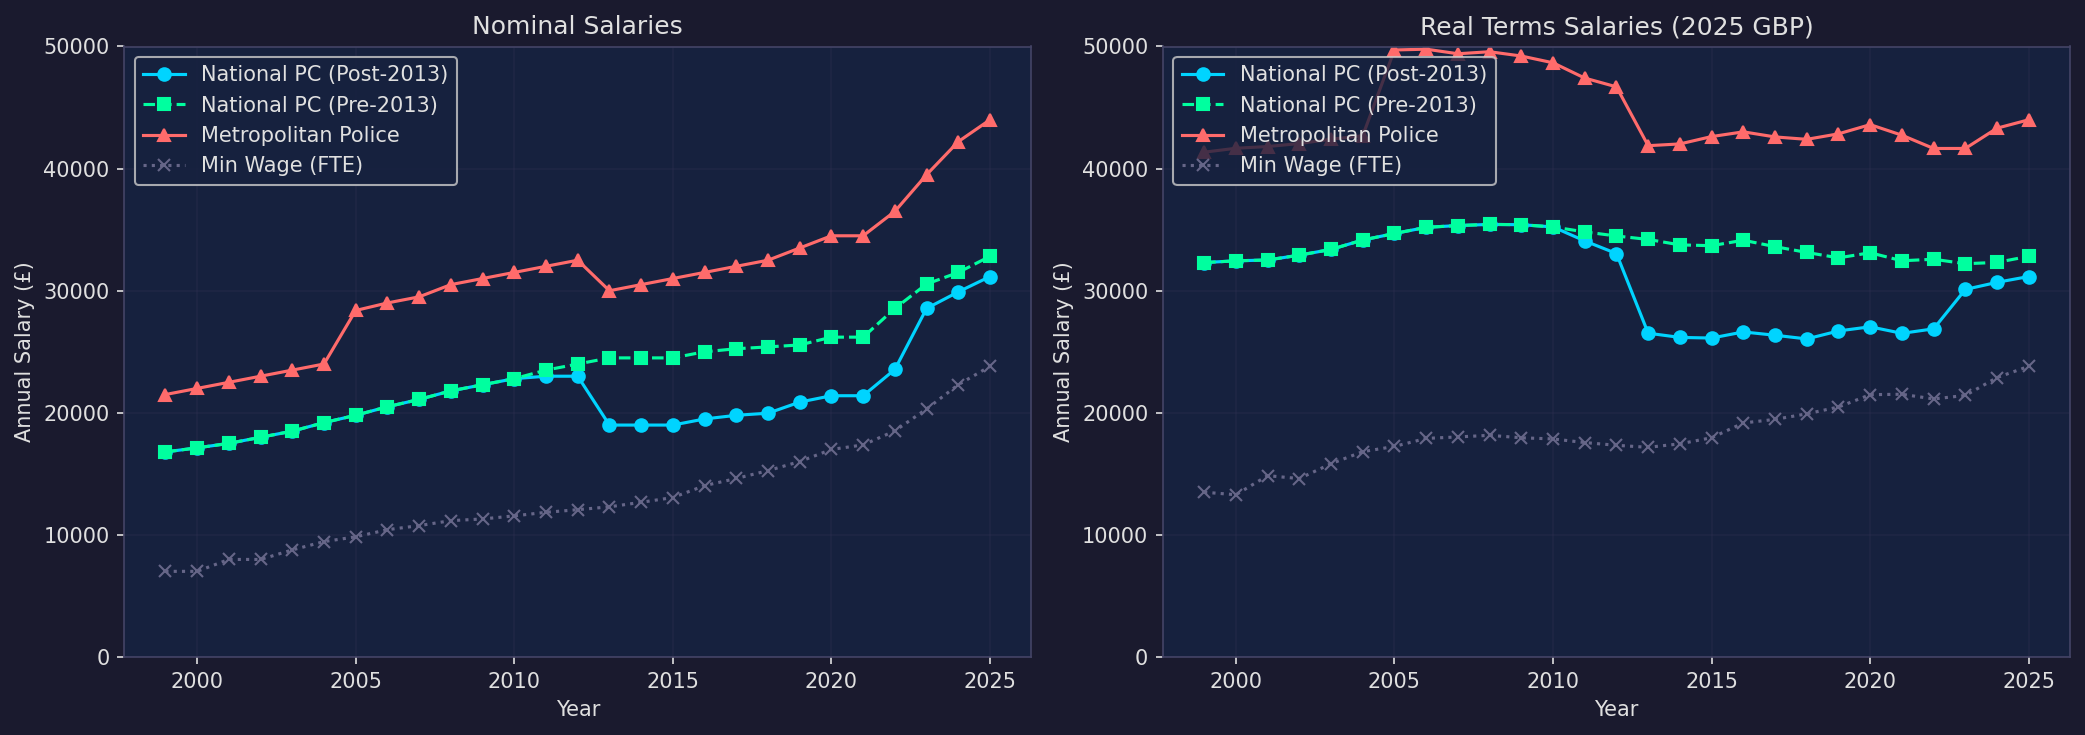

In [2]:
# | echo: false
# | classes: dark-plot
# | fig-cap: "Nominal and real-term starting salaries for Police Constables in England and Wales, 1999-2025. The post-2013 scale applies to new entrants after the Winsor Review."
# | label: fig-real-terms

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nominal
ax = axes[0]
ax.plot(df['Year'], df['PC_Nominal'], marker='o', label='National PC (Post-2013)', color='#00d4ff')
ax.plot(df['Year'], df['PC_Pre13_Nominal'], marker='s', linestyle='--', label='National PC (Pre-2013)', color='#00ff9f')
ax.plot(df['Year'], df['Met_Nominal'], marker='^', label='Metropolitan Police', color='#ff6b6b')
ax.plot(df['Year'], df['MinWage_Annual'], marker='x', linestyle=':', label='Min Wage (FTE)', color='#666688')
ax.set_title('Nominal Salaries')
ax.set_ylabel('Annual Salary (£)')
ax.set_xlabel('Year')
ax.legend(loc='upper left')
ax.set_ylim(0, 50000)

# Real terms
ax = axes[1]
ax.plot(df['Year'], df['PC_Real'], marker='o', label='National PC (Post-2013)', color='#00d4ff')
ax.plot(df['Year'], df['PC_Pre13_Real'], marker='s', linestyle='--', label='National PC (Pre-2013)', color='#00ff9f')
ax.plot(df['Year'], df['Met_Real'], marker='^', label='Metropolitan Police', color='#ff6b6b')
ax.plot(df['Year'], df['MinWage_Real'], marker='x', linestyle=':', label='Min Wage (FTE)', color='#666688')
ax.set_title('Real Terms Salaries (2025 GBP)')
ax.set_ylabel('Annual Salary (£)')
ax.set_xlabel('Year')
ax.legend(loc='upper left')
ax.set_ylim(0, 50000)

plt.tight_layout()
plt.show()


The right-hand panel tells the real story. In 2025 pounds, a constable starting in 2000 on £17,133 should be earning roughly £40,000 today to have equivalent purchasing power. The actual 2025 post-2013 starter salary is £31,164 — a real-terms cut of about 22%. Even the pre-2013 scale (£32,820 in 2025) barely matches the inflation-adjusted 2000 starter.

## The 2013 Winsor Cut

The most dramatic single event in this dataset is the Winsor Review. In 2013, the starting salary for new constables was slashed from roughly £23,000 to £19,000. The rationale was to modernise police pay and make it more affordable during the austerity era. The result was a two-tier system that persists today.

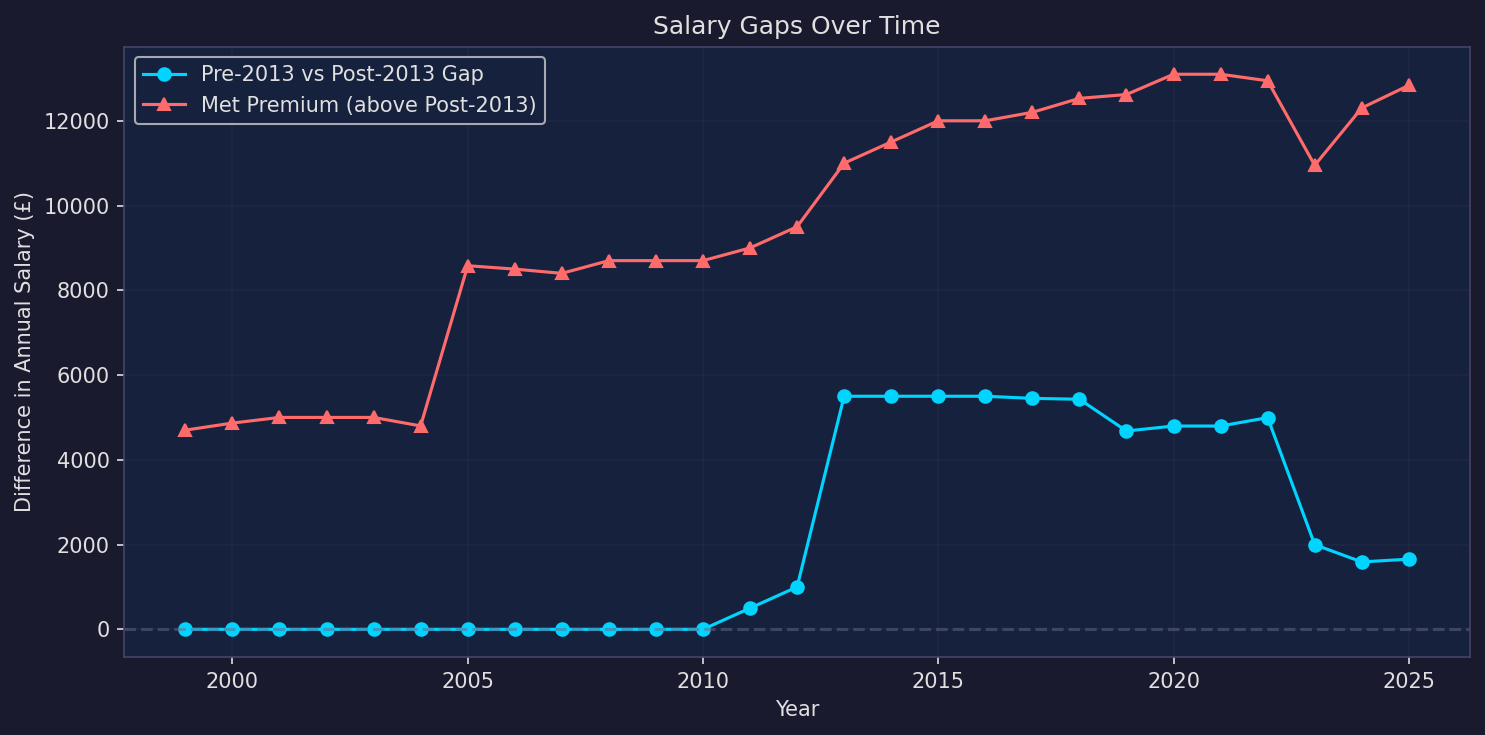

In [3]:
# | echo: false
# | classes: dark-plot
# | fig-cap: "The gap between pre-2013 and post-2013 starting salaries, and the Metropolitan Police premium."
# | label: fig-gap

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Year'], df['PC_Pre13_Nominal'] - df['PC_Nominal'], marker='o', label='Pre-2013 vs Post-2013 Gap', color='#00d4ff')
ax.plot(df['Year'], df['Met_Nominal'] - df['PC_Nominal'], marker='^', label='Met Premium (above Post-2013)', color='#ff6b6b')
ax.axhline(y=0, color='#666688', linestyle='--', alpha=0.5)
ax.set_title('Salary Gaps Over Time')
ax.set_ylabel('Difference in Annual Salary (£)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()


Before 2013 there was no gap — everyone started on the same scale. After 2013, new entrants found themselves on a lower ladder that has never fully caught up. The Met premium, meanwhile, has remained relatively stable at around £10,000 to £13,000 above the post-2013 national starter.

## Police Pay as a Multiple of Minimum Wage

Perhaps the clearest way to see the erosion is to compare PC starting pay against the minimum wage. In 1999, a new constable earned 2.4 times the full-time minimum wage. By 2013, that had collapsed to 1.5 times.

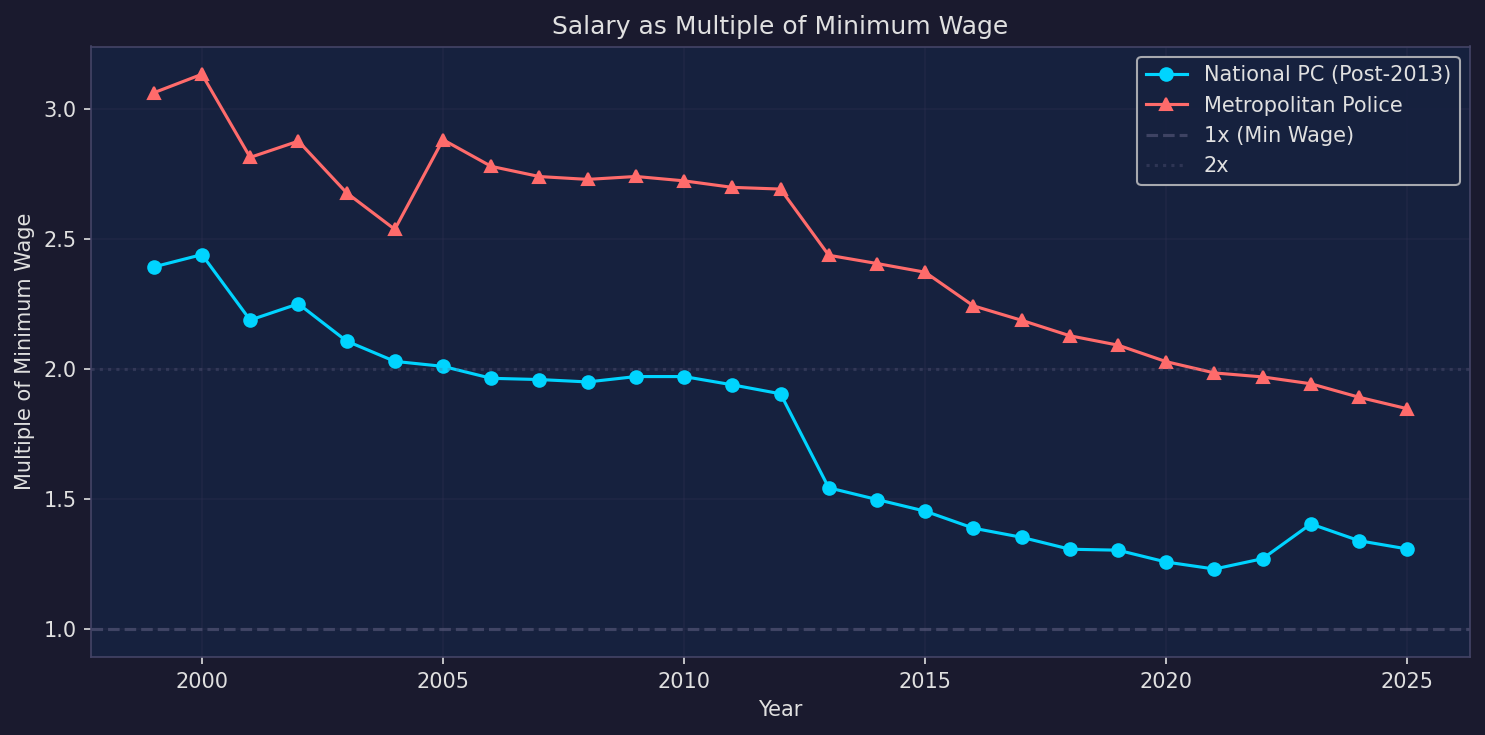

In [4]:
# | echo: false
# | classes: dark-plot
# | fig-cap: "Starting salary expressed as a multiple of the full-time equivalent minimum wage."
# | label: fig-multiple

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Year'], df['PC_vs_MinWage'], marker='o', label='National PC (Post-2013)', color='#00d4ff')
ax.plot(df['Year'], df['Met_vs_MinWage'], marker='^', label='Metropolitan Police', color='#ff6b6b')
ax.axhline(y=1.0, color='#666688', linestyle='--', alpha=0.5, label='1x (Min Wage)')
ax.axhline(y=2.0, color='#666688', linestyle=':', alpha=0.3, label='2x')
ax.set_title('Salary as Multiple of Minimum Wage')
ax.set_ylabel('Multiple of Minimum Wage')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()


The post-2013 national starter in 2025 earns just 1.3 times the minimum wage. The Metropolitan Police holds up better at roughly 1.85 times, but that is still well below the 3.1x multiple it enjoyed in 2005.

## A Quarter-Century of Erosion

Indexing everything to 2000 makes the long-term trend stark. A value of 100 means the salary has exactly kept pace with inflation. Anything below 100 is a real-terms pay cut.

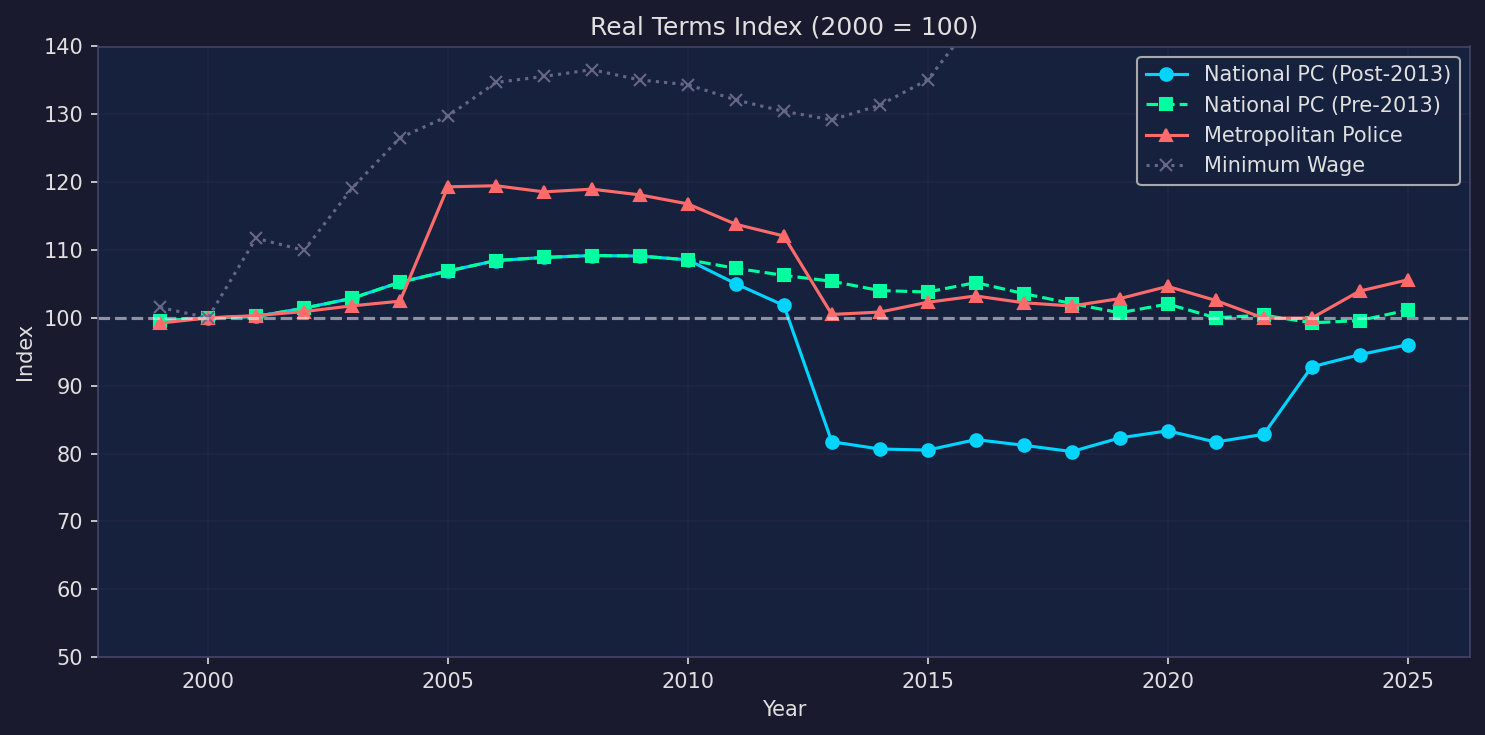

In [5]:
# | echo: false
# | classes: dark-plot
# | fig-cap: "Real-terms salary index, 2000 = 100. Values below 100 indicate purchasing power has fallen since 2000."
# | label: fig-index

base_pc = df.loc[df['Year'] == 2000, 'PC_Real'].values[0]
base_met = df.loc[df['Year'] == 2000, 'Met_Real'].values[0]
base_mw = df.loc[df['Year'] == 2000, 'MinWage_Real'].values[0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Year'], df['PC_Real'] / base_pc * 100, marker='o', label='National PC (Post-2013)', color='#00d4ff')
ax.plot(df['Year'], df['PC_Pre13_Real'] / base_pc * 100, marker='s', linestyle='--', label='National PC (Pre-2013)', color='#00ff9f')
ax.plot(df['Year'], df['Met_Real'] / base_met * 100, marker='^', label='Metropolitan Police', color='#ff6b6b')
ax.plot(df['Year'], df['MinWage_Real'] / base_mw * 100, marker='x', linestyle=':', label='Minimum Wage', color='#666688')
ax.axhline(y=100, color='white', linestyle='--', alpha=0.5)
ax.set_title('Real Terms Index (2000 = 100)')
ax.set_ylabel('Index')
ax.set_xlabel('Year')
ax.legend()
ax.set_ylim(50, 140)
plt.tight_layout()
plt.show()


The minimum wage itself has roughly kept pace with inflation since 2000 — its index hovers around 100. But police starting pay fell off a cliff in 2013 and has never recovered. The post-2013 scale sits at roughly 96 indexed to 2000, while the pre-2013 scale has slipped to about 101. The Metropolitan Police has fared worst of all, dropping to around 88.

## The Metropolitan Police Premium

London policing has always paid more. The Met's starter package includes basic pay plus London Weighting (£3,150 since 2024) and a London Allowance that has varied over time. In 2005, the Met starter package was £28,383 — roughly 44% above the national PC starter.

In 2024, the Met advertises a starting salary of £42,210. That sounds generous, and it is — but it represents a real-terms decline from the mid-2000s peak. The premium over the national scale has held steady at around 40%, but both have been dragged down by the same inflationary pressures.

## Summary Data

For reference, the full dataset is reproduced below.

In [6]:
# | echo: false
# | classes: dark-plot
summary = df[['Year', 'MinWage_Hourly', 'PC_Nominal', 'PC_Real', 'Met_Nominal', 'Met_Real', 'PC_vs_MinWage', 'Met_vs_MinWage']].copy()
summary.columns = ['Year', 'Min Wage (hr)', 'PC Start (£)', 'PC Real (£)', 'Met Start (£)', 'Met Real (£)', 'PC vs MinWage', 'Met vs MinWage']
summary = summary.round(2)
print(summary.to_string(index=False))


 Year  Min Wage (hr)  PC Start (£)  PC Real (£)  Met Start (£)  Met Real (£)  PC vs MinWage  Met vs MinWage
 1999           3.60         16800     32307.69          21500      41346.15           2.39            3.06
 2000           3.60         17133     32448.86          22000      41666.67           2.44            3.13
 2001           4.10         17500     32516.89          22500      41807.43           2.19            2.81
 2002           4.10         18000     32912.23          23000      42054.52           2.25            2.88
 2003           4.50         18500     33382.55          23500      42404.86           2.11            2.68
 2004           4.85         19200     34152.65          24000      42690.82           2.03            2.54
 2005           5.05         19803     34686.78          28383      49715.45           2.01            2.88
 2006           5.35         20500     35190.39          29000      49781.52           1.97            2.78
 2007           5.52        

## Key Findings

1. **A real-terms pay cut of roughly 22%**: A constable starting in 2000 on £17,133 would need about £40,000 in 2025 to have equivalent purchasing power. The actual post-2013 starter salary is £31,164.

2. **The Winsor cut created a two-tier system**: New entrants from April 2013 onwards started on a lower scale that has never caught up. The gap between pre-2013 and post-2013 starters persists today.

3. **The minimum wage gap has collapsed**: In 1999, a PC starter earned 2.4 times the minimum wage. By 2025, that has fallen to 1.3 times for post-2013 entrants. The Met holds up better at 1.85 times, but that is still well below historical levels.

4. **The Metropolitan Police premium has eroded too**: While the Met still pays roughly 40% above the national scale, its real-terms value has declined since the mid-2000s peak.

## Data Quality Notes

- Solid data points: Hansard (2000, 2005), Winsor reforms (2013), Metfriendly scales (2019/20), Police Federation (2024/25), Met Police careers site (2024/25).

- Interpolated years (2001-2004, 2006-2012, 2014-2018, 2020-2023 Met) are estimated from known pay awards and percentage uplifts.

- Police pay typically takes effect in September; minimum wage changes in April. Figures are calendar-year snapshots.

- London allowance structures changed over time. The Met figures include all London-specific payments but may not capture every historical variation.